# Integrative Protocol for Protein–Protein Interaction and Gene Expression Analysis

This notebook builds condition-specific active PPI networks by integrating a STRING-derived reference interaction network with expression-supported active genes. 
---

## Section 1 — Setup: Imports and User Parameters

In [22]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import gzip
import shutil
import random

# ── Third-party ───────────────────────────────────────────────────────────────
import requests
import numpy as np
import pandas as pd
import networkx as nx
import community as community_louvain          # python-louvain
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path
from collections import defaultdict 
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (normalized_mutual_info_score,
                              adjusted_rand_score)

print("All libraries imported successfully.")

All libraries imported successfully.


In [23]:
# ── User-defined parameters ───────────────────────────────────────────────────
TAXID          = "83332"       # M. tuberculosis H37Rv taxonomy ID
STRING_VERSION = "v12.0"       # STRING database version
MIN_SCORE      = 700           # High-confidence interaction threshold (≥700)
RANDOM_SEED    = 42            # Reproducibility for layouts/permutation/Louvain

# Expression files (BED-like, tab-separated, GTF+count+TPM format)
LOG_EXPR_FILE    = "Mtbgtf_SRR18455932_exponential.bed"
STRESS_EXPR_FILE = "Mtbgtf_SRR18455925_starvation.bed"

# Derived file names
RAW_GZ  = f"{TAXID}.protein.links.{STRING_VERSION}.txt.gz"
RAW_TXT = f"{TAXID}.protein.links.{STRING_VERSION}.txt"

OUTDIR = Path("outputs")
OUTDIR.mkdir(exist_ok=True)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Organism  : M. tuberculosis H37Rv (TAXID {TAXID})")
print(f"STRING    : {STRING_VERSION}, min score {MIN_SCORE}")
print(f"Random seed: {RANDOM_SEED}")
print(f"Log file  : {LOG_EXPR_FILE}")
print(f"Stress file: {STRESS_EXPR_FILE}")
print(f"Output dir: {OUTDIR}/")

Organism  : M. tuberculosis H37Rv (TAXID 83332)
STRING    : v12.0, min score 700
Random seed: 42
Log file  : Mtbgtf_SRR18455932_exponential.bed
Stress file: Mtbgtf_SRR18455925_starvation.bed
Output dir: outputs/


## Section 2 — Download and Prepare the STRING Interaction Network

The STRING bulk file is downloaded once and cached locally.  
Each row contains two protein identifiers and a combined confidence score.

In [24]:
FILE_URL = (
    f"https://stringdb-downloads.org/download/"
    f"protein.links.{STRING_VERSION}/{RAW_GZ}"
)

# Download only if not already present
if not os.path.exists(RAW_GZ):
    print(f"Downloading {RAW_GZ} ...")
    with requests.get(FILE_URL, stream=True, timeout=300) as r:
        r.raise_for_status()
        with open(RAW_GZ, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
    print("Download complete.")
else:
    print(f"File already exists locally: {RAW_GZ}")

# Decompress only if not already done
if not os.path.exists(RAW_TXT):
    print("Decompressing ...")
    with gzip.open(RAW_GZ, "rb") as f_in, open(RAW_TXT, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    print("Decompression complete.")
else:
    print(f"Decompressed file already exists: {RAW_TXT}")

Download complete.
Decompressing ...
Decompression complete.


In [25]:
# ── Load, filter, and clean the interaction table ────────────────────────────
ppi_raw = pd.read_csv(RAW_TXT, sep=r"\s+", header=0)  # header=0: use column-name row as header

# Coerce score to numeric; drop rows with invalid scores
ppi_raw["combined_score"] = pd.to_numeric(ppi_raw["combined_score"], errors="coerce")
ppi_raw = ppi_raw.dropna(subset=["combined_score"])

# Apply confidence threshold
ppi_raw = ppi_raw[ppi_raw["combined_score"] >= MIN_SCORE].copy()
print(f"High-confidence STRING rows retained: {len(ppi_raw):,}")

# Strip species prefix from STRING protein identifiers (e.g. "83332.Rv0001" → "Rv0001")
prefix = f"{TAXID}."
ppi = ppi_raw[["protein1", "protein2", "combined_score"]].copy()
ppi["geneA"] = ppi["protein1"].astype(str).str.replace(prefix, "", regex=False)
ppi["geneB"] = ppi["protein2"].astype(str).str.replace(prefix, "", regex=False)
ppi = ppi[["geneA", "geneB", "combined_score"]].dropna().copy()

# STRING bulk files can contain reciprocal entries (A-B and B-A). For an undirected
# PPI network, canonicalize each pair and retain the maximum confidence score.
pairs = np.sort(ppi[["geneA", "geneB"]].to_numpy(dtype=str), axis=1)
ppi["geneA"] = pairs[:, 0]
ppi["geneB"] = pairs[:, 1]
ppi = ppi[ppi["geneA"] != ppi["geneB"]].copy()  # remove self-loops, if any
ppi = (ppi.groupby(["geneA", "geneB"], as_index=False)["combined_score"]
          .max()
          .reset_index(drop=True))

ppi.to_csv(OUTDIR / "cleaned_STRING_high_confidence_ppi.tsv", sep="\t", index=False)

print(f"Unique undirected gene–gene interactions: {len(ppi):,}")
print(f"Saved cleaned PPI table: {OUTDIR / 'cleaned_STRING_high_confidence_ppi.tsv'}")
ppi.head()

High-confidence STRING rows retained: 60,058
Unique undirected gene–gene interactions: 30,029
Saved cleaned PPI table: outputs\cleaned_STRING_high_confidence_ppi.tsv


,geneA,geneB,combined_score
0,Rv0001,Rv0002,998
1,Rv0001,Rv0003,958
2,Rv0001,Rv0005,841
3,Rv0001,Rv0006,820
4,Rv0001,Rv0058,959


In [26]:
# ── Build static (reference) PPI network ─────────────────────────────────────
# The STRING combined_score is retained as an edge attribute. It is used later
# for weighted Louvain community detection and PageRank.
G_static = nx.from_pandas_edgelist(
    ppi,
    source="geneA",
    target="geneB",
    edge_attr="combined_score",
    create_using=nx.Graph()
)

print(f"Static network — nodes: {G_static.number_of_nodes():,}  |  "
      f"edges: {G_static.number_of_edges():,}")

Static network — nodes: 3,789  |  edges: 30,029


## Section 3 — Load Gene Expression Data

The BED-like files contain genomic coordinates, feature annotations, raw read counts, and a final normalized expression column. In this notebook the final column is handled as `expr`. If this column is true TPM, the total across genes should be close to 1,000,000; otherwise, describe it more cautiously as a normalized expression value.

Only **gene-level** rows are retained.

In [27]:
def load_expression(path: str) -> pd.DataFrame:
    """
    Parse a GTF+expression BED-like file and return a two-column DataFrame:
    gene (str) | expr (float).

    Expected columns (0-indexed):
      3  = gene identifier
      7  = feature type  ('gene', 'exon', …)
      -1 = normalized expression value used for activity filtering
    """
    df = pd.read_csv(path, sep="\t", header=None, low_memory=False)

    if df.shape[1] < 12:
        raise ValueError(f"{path}: expected ≥12 columns, found {df.shape[1]}")

    df = df.rename(columns={3: "gene", 7: "feature", df.shape[1] - 1: "expr"})
    df = df[df["feature"] == "gene"].copy()
    df["gene"] = df["gene"].astype(str).str.strip()
    df["expr"] = pd.to_numeric(df["expr"], errors="coerce")
    df = df.dropna(subset=["gene", "expr"]).reset_index(drop=True)
    return df[["gene", "expr"]]


expr_log    = load_expression(LOG_EXPR_FILE)
expr_stress = load_expression(STRESS_EXPR_FILE)

for label, df in [("Log (exponential)", expr_log), ("Stress (starvation)", expr_stress)]:
    expr_sum = df["expr"].sum()
    expr_min = df["expr"].min()
    expr_max = df["expr"].max()
    print(f"{label}: {len(df):,} genes  |  expression range: {expr_min:.3f} – {expr_max:.3f}  |  sum: {expr_sum:,.3f}")
    if expr_max > 1_000_000 or not (900_000 <= expr_sum <= 1_100_000):
        print("  NOTE: The final column does not behave like standard TPM. In the chapter, call it a normalized expression value unless TPM normalization is verified.")


Log (exponential): 4,008 genes  |  expression range: 0.000 – 810825.768  |  sum: 3,004,996.107
  NOTE: The final column does not behave like standard TPM. In the chapter, call it a normalized expression value unless TPM normalization is verified.
Stress (starvation): 4,008 genes  |  expression range: 0.000 – 2866027.727  |  sum: 5,369,923.424
  NOTE: The final column does not behave like standard TPM. In the chapter, call it a normalized expression value unless TPM normalization is verified.


## Section 4 — Median-Based Activity Filtering

Genes with normalized expression values **at or above** the per-condition median are classified as *active*. This provides a simple condition-specific activity definition without requiring differential-expression testing. These active genes should not be described as DEGs unless a separate statistical differential-expression analysis is performed.

In [28]:
median_log    = expr_log["expr"].median()
median_stress = expr_stress["expr"].median()

active_log    = set(expr_log.loc[expr_log["expr"]    >= median_log,    "gene"])
active_stress = set(expr_stress.loc[expr_stress["expr"] >= median_stress, "gene"])

print(f"Log    — median expression: {median_log:.3f}  |  active genes: {len(active_log):,}")
print(f"Stress — median expression: {median_stress:.3f}  |  active genes: {len(active_stress):,}")
print(f"\nGenes active in both conditions : {len(active_log & active_stress):,}")
print(f"Log-only active genes           : {len(active_log - active_stress):,}")
print(f"Stress-only active genes        : {len(active_stress - active_log):,}")


Log    — median expression: 161.026  |  active genes: 2,004
Stress — median expression: 9.906  |  active genes: 2,004

Genes active in both conditions : 1,476
Log-only active genes           : 528
Stress-only active genes        : 528


## Section 5 — Construct Condition-Specific PPI Networks

Active-gene sets are overlaid onto the static network by inducing subgraphs.  
Only edges where *both* endpoints are active in that condition are retained.

In [29]:
G_log    = G_static.subgraph(active_log).copy()
G_stress = G_static.subgraph(active_stress).copy()

for label, G in [("Log", G_log), ("Stress", G_stress)]:
    print(f"{label} network — nodes: {G.number_of_nodes():,}  |  "
          f"edges: {G.number_of_edges():,}")

Log network — nodes: 1,893  |  edges: 13,088
Stress network — nodes: 1,847  |  edges: 10,847


## Section 6 — Centrality Analysis

Five complementary metrics are computed for each condition-specific network:

| Metric | What it captures |
|---|---|
| **Degree** | Local connectivity (number of direct neighbours) |
| **Betweenness** | Bottleneck influence (fraction of shortest paths through a node) |
| **Closeness** | Global reach (inverse average distance to all other nodes) |
| **Eigenvector** | Influence weighted by neighbour importance |
| **PageRank** | Iterative influence propagation (analogous to Google's algorithm) |

In [30]:
def compute_centrality(G: nx.Graph, label: str) -> pd.DataFrame:
    """Return a DataFrame of centrality metrics for all nodes in G."""
    print(f"Computing centrality for {label} network ({G.number_of_nodes():,} nodes) …")
    
    if G.number_of_nodes() == 0:
        return pd.DataFrame(columns=["gene", "degree", "weighted_degree", "betweenness", "closeness", "eigenvector", "pagerank"])

    # Degree is kept unweighted because it is biologically interpretable as the
    # number of direct partners. Weighted degree summarizes cumulative STRING confidence.
    weighted_degree = dict(G.degree(weight="combined_score"))

    # STRING combined_score is a confidence score, not a distance. Therefore,
    # betweenness/closeness are computed on the unweighted topology.
    betweenness = nx.betweenness_centrality(G, normalized=True)
    closeness   = nx.closeness_centrality(G)

    try:
        eigenvector = nx.eigenvector_centrality(G, max_iter=1000, weight="combined_score")
    except nx.PowerIterationFailedConvergence:
        print("  Warning: eigenvector centrality did not converge; using unweighted fallback.")
        eigenvector = nx.eigenvector_centrality(G, max_iter=2000)

    pagerank = nx.pagerank(G, weight="combined_score")

    df = pd.DataFrame({
        "gene":            list(G.nodes()),
        "degree":          [G.degree(n) for n in G.nodes()],
        "weighted_degree": [weighted_degree[n] for n in G.nodes()],
        "betweenness":     [betweenness[n] for n in G.nodes()],
        "closeness":       [closeness[n] for n in G.nodes()],
        "eigenvector":     [eigenvector[n] for n in G.nodes()],
        "pagerank":        [pagerank[n] for n in G.nodes()],
    })
    print(f"  Done.\n")
    return df


cent_log    = compute_centrality(G_log,    "Log")
cent_stress = compute_centrality(G_stress, "Stress")

cent_log.to_csv(OUTDIR / "centrality_log.tsv", sep="\t", index=False)
cent_stress.to_csv(OUTDIR / "centrality_stress.tsv", sep="\t", index=False)

print("Top 10 genes by degree — Log phase:")
print(cent_log.sort_values("degree", ascending=False)
              .head(10)[["gene", "degree", "weighted_degree", "betweenness", "pagerank"]]
              .to_string(index=False))

Computing centrality for Log network (1,893 nodes) …
  Done.

Computing centrality for Stress network (1,847 nodes) …
  Done.

Top 10 genes by degree — Log phase:
   gene  degree  weighted_degree  betweenness  pagerank
 Rv0701     135           123570     0.020009  0.002671
 Rv0721     133           121194     0.010207  0.002491
 Rv0682     133           122900     0.012296  0.002579
 Rv0704     130           119212     0.005358  0.002374
Rv3443c     129           118065     0.010558  0.002394
 Rv0702     128           118528     0.005924  0.002352
 Rv0667     124           111579     0.022333  0.002713
 Rv0683     122           112358     0.006136  0.002240
Rv3459c     121           112547     0.004310  0.002213
Rv2890c     121           111721     0.010420  0.002293


## Section 7 — Union-Based Centrality Core

A gene is included in the *centrality core* if it scores **at or above the median**  
in **any** of the five metrics.  The union captures robust hubs without favouring  
a single measure.

In [31]:
def centrality_core(df: pd.DataFrame) -> set:
    """Return the union of above-median genes across centrality metrics."""
    metrics = ["degree", "weighted_degree", "betweenness", "closeness", "eigenvector", "pagerank"]
    return set().union(*[
        set(df.loc[df[col] >= df[col].median(), "gene"])
        for col in metrics
    ])


core_log    = centrality_core(cent_log)
core_stress = centrality_core(cent_stress)

shared_core      = core_log & core_stress       # conserved hubs
log_only_core    = core_log - core_stress       # log-specific core genes
stress_only_core = core_stress - core_log       # stress-specific core genes

print(f"Log centrality core      : {len(core_log):,} genes")
print(f"Stress centrality core   : {len(core_stress):,} genes")
print(f"Shared core              : {len(shared_core):,}")
print(f"Log-only core            : {len(log_only_core):,}")
print(f"Stress-only core         : {len(stress_only_core):,}")

Log centrality core      : 1,367 genes
Stress centrality core   : 1,364 genes
Shared core              : 940
Log-only core            : 427
Stress-only core         : 424


In [32]:
# Per-metric correlation (log vs. stress) — how conserved is the centrality hierarchy?
common = pd.merge(cent_log, cent_stress, on="gene", suffixes=("_log", "_stress"))

print("Per-metric Spearman correlation (log vs. stress):")
for m in ["degree", "weighted_degree", "betweenness", "closeness", "eigenvector", "pagerank"]:
    r, _ = spearmanr(common[f"{m}_log"], common[f"{m}_stress"])
    print(f"  {m:16s}: ρ = {r:.3f}")

Per-metric Spearman correlation (log vs. stress):
  degree          : ρ = 0.953
  weighted_degree : ρ = 0.954
  betweenness     : ρ = 0.852
  closeness       : ρ = 0.956
  eigenvector     : ρ = 0.953
  pagerank        : ρ = 0.895


## Section 8 — Community Detection (Louvain Algorithm)

The Louvain algorithm maximises network modularity to partition genes into  
functionally coherent communities.  Resolution = 1.0 (default).

In [33]:
def detect_communities(G: nx.Graph, label: str, resolution: float = 1.0) -> pd.DataFrame:
    """
    Run the Louvain algorithm and return a DataFrame mapping gene → community ID.
    Community IDs are re-indexed by size (0 = largest).
    """
    partition = community_louvain.best_partition(
        G,
        resolution=resolution,
        random_state=RANDOM_SEED,
        weight="combined_score"
    )
    n_comms = len(set(partition.values()))
    print(f"{label}: {n_comms} communities detected")

    df = pd.DataFrame({
        "gene":      list(partition.keys()),
        "community": list(partition.values()),
    })

    # Re-label communities by descending size so community 0 is always the largest
    size_order = (df["community"].value_counts()
                                 .reset_index()
                                 .reset_index()
                                 .rename(columns={"index": "new_id", "community": "old_id"}))
    remap = dict(zip(size_order["old_id"], size_order["new_id"]))
    df["community"] = df["community"].map(remap)

    print(f"  Largest community: {df['community'].value_counts().iloc[0]:,} genes")
    return df


comm_log    = detect_communities(G_log,    "Log")
comm_stress = detect_communities(G_stress, "Stress")

comm_log.to_csv(OUTDIR    / "communities_log.tsv",    sep="\t", index=False)
comm_stress.to_csv(OUTDIR / "communities_stress.tsv", sep="\t", index=False)
print(f"\nSaved community files to {OUTDIR}/")

Log: 130 communities detected
  Largest community: 248 genes
Stress: 162 communities detected
  Largest community: 293 genes

Saved community files to outputs/


In [34]:
# Community structure comparison using shared genes
common_genes  = list(set(comm_log["gene"]) & set(comm_stress["gene"]))
labels_log    = comm_log.set_index("gene").loc[common_genes, "community"].values
labels_stress = comm_stress.set_index("gene").loc[common_genes, "community"].values

nmi = normalized_mutual_info_score(labels_log, labels_stress)
ari = adjusted_rand_score(labels_log, labels_stress)

print(f"Genes evaluated (shared): {len(common_genes):,}")
print(f"NMI  (0 = independent, 1 = identical): {nmi:.4f}")
print(f"ARI  (0 = random,      1 = identical): {ari:.4f}")
print("\nInterpretation: NMI/ARI quantify how similar the community assignments are between conditions. Moderate values indicate partial conservation with measurable reorganization.")

Genes evaluated (shared): 1,378
NMI  (0 = independent, 1 = identical): 0.6601
ARI  (0 = random,      1 = identical): 0.4707

Interpretation: NMI/ARI quantify how similar the community assignments are between conditions. Moderate values indicate partial conservation with measurable reorganization.


## Section 9 — Chapter Protocol Figures and Visualisations

This section generates clean figure for the book chapter protocol. The figures are designed to show how a static PPI/functional-association network is converted into condition-specific active networks after integration with gene expression data.




In [35]:
# ── Plot style and helper functions ──────────────────────────────────────────
import math
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle, FancyArrowPatch, FancyBboxPatch

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 600,
})

FIGDIR = OUTDIR / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, filename: str):
    """Save a figure as both PNG and PDF for manuscript/chapter use."""
    png = FIGDIR / f"{filename}.png"
    pdf = FIGDIR / f"{filename}.pdf"
    fig.savefig(png, dpi=600, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    print(f"Saved: {png}")
    print(f"Saved: {pdf}")

def canonical_edge_set(G: nx.Graph) -> set:
    """Return undirected edges in canonical sorted tuple format."""
    return {tuple(sorted(e)) for e in G.edges()}

def top_shift_labels(df: pd.DataFrame, metric: str, n: int = 6) -> pd.DataFrame:
    """Return genes with the largest absolute centrality shift for labelling."""
    d = df.copy()
    d["abs_shift"] = (d[f"{metric}_stress"] - d[f"{metric}_log"]).abs()
    return d.nlargest(n, "abs_shift")


## Section 10 — Functional Enrichment Analysis of Expression-Supported Network Genes




In [36]:
# ── Define functional enrichment gene sets ───────────────────────────────────

# Background/universe for enrichment:
# only genes that could enter the analysis: present in STRING static network and
# present in both expression tables.
background_genes = sorted(set(G_static.nodes()) & set(expr_log["gene"]) & set(expr_stress["gene"]))

nodes_static = set(G_static.nodes())
nodes_log = set(G_log.nodes())
nodes_stress = set(G_stress.nodes())

log_specific_genes = sorted(nodes_log - nodes_stress)
stress_specific_genes = sorted(nodes_stress - nodes_log)
common_active_genes = sorted(nodes_log & nodes_stress)
inactive_static_genes = sorted(nodes_static - (nodes_log | nodes_stress))

condition_enrichment_sets = {
    "Log active network genes": sorted(nodes_log & set(background_genes)),
    "Stress active network genes": sorted(nodes_stress & set(background_genes)),
    "Common active network genes": sorted(set(common_active_genes) & set(background_genes)),
}

print(f"Enrichment background genes: {len(background_genes):,}")

print("\nStrict network-state counts:")
print(f"  Log active network genes          : {len(nodes_log):,}")
print(f"  Stress active network genes       : {len(nodes_stress):,}")
print(f"  Common active network genes       : {len(common_active_genes):,}")
print(f"  Log-specific active network genes : {len(log_specific_genes):,}")
print(f"  Stress-specific active network genes: {len(stress_specific_genes):,}")
print(f"  Static-only/inactive genes        : {len(inactive_static_genes):,}")

# -------------------------------------------------------------------------
# Expression-rank-shift gene sets
# -------------------------------------------------------------------------
# Direct TPM fold-change may be misleading if the two files were normalized
# differently. Therefore, we use within-condition expression percentile ranks.
# delta_rank = stress expression rank percentile - log expression rank percentile.
# Positive values indicate stress-biased relative activity; negative values
# indicate log-biased relative activity.

expr_pair = (
    expr_log.rename(columns={"expr": "expr_log"})
    .merge(expr_stress.rename(columns={"expr": "expr_stress"}), on="gene", how="inner")
)

expr_pair = expr_pair[expr_pair["gene"].isin(set(background_genes) & (nodes_log | nodes_stress))].copy()

expr_pair["rank_log"] = expr_pair["expr_log"].rank(pct=True, method="average")
expr_pair["rank_stress"] = expr_pair["expr_stress"].rank(pct=True, method="average")
expr_pair["delta_rank_stress_minus_log"] = expr_pair["rank_stress"] - expr_pair["rank_log"]

# Optional fold-change column for inspection only. Rank-shift is used for selection.
pseudo = max(1e-6, min(expr_pair["expr_log"].median(), expr_pair["expr_stress"].median()) * 0.01)
expr_pair["log2FC_stress_vs_log"] = np.log2((expr_pair["expr_stress"] + pseudo) / (expr_pair["expr_log"] + pseudo))

# Select top and bottom fraction by expression-rank shift.
RANK_SHIFT_FRACTION = 0.20
n_select = max(100, int(len(expr_pair) * RANK_SHIFT_FRACTION))

expr_pair_sorted = expr_pair.sort_values("delta_rank_stress_minus_log").reset_index(drop=True)

log_biased_genes = sorted(set(expr_pair_sorted.head(n_select)["gene"]) & nodes_log)
stress_biased_genes = sorted(set(expr_pair_sorted.tail(n_select)["gene"]) & nodes_stress)

# If intersection with active networks makes a set very small, relax to the rank-selected set.
if len(log_biased_genes) < 50:
    log_biased_genes = sorted(set(expr_pair_sorted.head(n_select)["gene"]))
if len(stress_biased_genes) < 50:
    stress_biased_genes = sorted(set(expr_pair_sorted.tail(n_select)["gene"]))

rank_shift_enrichment_sets = {
    "Log-biased active network genes": log_biased_genes,
    "Stress-biased active network genes": stress_biased_genes,
}

expr_pair.to_csv(OUTDIR / "expression_rank_shift_table.csv", index=False)

print("\nExpression-rank-shift enrichment sets:")
print(f"  Log-biased active network genes    : {len(log_biased_genes):,}")
print(f"  Stress-biased active network genes : {len(stress_biased_genes):,}")
print(f"  Rank-shift fraction used           : {RANK_SHIFT_FRACTION:.0%}")
print(f"  Saved: {OUTDIR / 'expression_rank_shift_table.csv'}")


Enrichment background genes: 3,687

Strict network-state counts:
  Log active network genes          : 1,893
  Stress active network genes       : 1,847
  Common active network genes       : 1,378
  Log-specific active network genes : 515
  Stress-specific active network genes: 469
  Static-only/inactive genes        : 1,427

Expression-rank-shift enrichment sets:
  Log-biased active network genes    : 472
  Stress-biased active network genes : 472
  Rank-shift fraction used           : 20%
  Saved: outputs\expression_rank_shift_table.csv


In [37]:
# ── STRING functional enrichment: robust API wrapper ─────────────────────────

from io import StringIO
import time
import re

STRING_API_BASES = [
    "https://version-12-0.string-db.org/api",
    "https://string-db.org/api",
]

ENRICHMENT_FDR_CUTOFF = 0.05
TOP_TERMS_PER_SET = 40
CALLER_IDENTITY = "dynamic_ppi_bookchapter_protocol"

# Preferred biological categories for plotting.
PREFERRED_PLOT_CATEGORIES = ["Process", "KEGG", "Function", "Keyword", "Component", "NetworkNeighborAL"]

# Only very broad terms are removed first. If a set becomes empty,
# the filter is automatically relaxed so stress panels do not disappear.
GENERIC_TERM_PATTERNS = [
    r"^cellular process$",
    r"^biological_process$",
    r"^molecular_function$",
    r"^cellular anatomical entity$",
    r"^catalytic activity$",
    r"^binding$",
    r"^membrane$",
    r"^plasma membrane$",
    r"^cytoplasm$",
    r"^cell periphery$",
    r"^metabolic process$",
    r"^primary metabolic process$",
]

def to_string_id(gene: str, taxid: str = TAXID) -> str:
    gene = str(gene).strip()
    if gene.startswith(f"{taxid}."):
        return gene
    return f"{taxid}.{gene}"

def to_string_ids(genes, taxid: str = TAXID):
    return sorted({to_string_id(g, taxid=taxid) for g in genes if pd.notna(g) and str(g).strip()})

def _post_string_api(method: str, payload: dict, timeout: int = 300) -> str:
    last_error = None
    for base in STRING_API_BASES:
        url = f"{base}/tsv/{method}"
        try:
            response = requests.post(url, data=payload, timeout=timeout)
            response.raise_for_status()
            text = response.text
            if text.strip().lower().startswith("error"):
                raise RuntimeError(text.strip()[:500])
            return text
        except Exception as e:
            last_error = e
            print(f"STRING API attempt failed at {url}: {e}")
    raise RuntimeError(f"All STRING API attempts failed for method '{method}'. Last error: {last_error}")

def _split_genes(x):
    if pd.isna(x):
        return []
    return [g.strip().replace(f"{TAXID}.", "") for g in str(x).split(",") if g.strip()]

def _standardize_string_enrichment(df: pd.DataFrame, gene_set_name: str, input_size: int, background_used: bool) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()

    df = df.copy()
    col_lower = {str(c).lower(): c for c in df.columns}

    term_col = col_lower.get("term")
    desc_col = col_lower.get("description", col_lower.get("term_description"))
    cat_col = col_lower.get("category")
    fdr_col = col_lower.get("fdr", col_lower.get("false_discovery_rate"))
    p_col = col_lower.get("p_value", col_lower.get("pvalue"))
    input_col = col_lower.get("inputgenes")
    pref_col = col_lower.get("preferrednames")

    df["gene_set"] = gene_set_name
    df["input_size"] = input_size
    df["background_used"] = background_used

    df["category"] = df[cat_col].astype(str) if cat_col else "Functional annotation"
    df["term_id"] = df[term_col].astype(str) if term_col else df.iloc[:, 0].astype(str)

    if desc_col:
        df["term_name"] = df[desc_col].astype(str)
    else:
        df["term_name"] = df["term_id"].astype(str)

    df["term_name"] = df["term_name"].replace({"nan": np.nan, "None": np.nan}).fillna(df["term_id"])
    df["display_term"] = np.where(
        df["term_name"].astype(str).str.lower() == df["term_id"].astype(str).str.lower(),
        df["term_id"].astype(str) + " [" + df["category"].astype(str) + "]",
        df["term_name"].astype(str)
    )

    df["fdr"] = pd.to_numeric(df[fdr_col], errors="coerce") if fdr_col else np.nan
    df["p_value"] = pd.to_numeric(df[p_col], errors="coerce") if p_col else np.nan

    if input_col:
        df["inputGenes_clean"] = df[input_col].astype(str)
        df["gene_ids"] = df["inputGenes_clean"].map(_split_genes)
    else:
        df["inputGenes_clean"] = ""
        df["gene_ids"] = [[] for _ in range(len(df))]

    if pref_col:
        df["preferredNames_clean"] = df[pref_col].astype(str)
    else:
        df["preferredNames_clean"] = ""

    if "number_of_genes" in col_lower:
        df["gene_count"] = pd.to_numeric(df[col_lower["number_of_genes"]], errors="coerce")
    else:
        df["gene_count"] = df["gene_ids"].map(len)

    df["gene_ratio"] = df["gene_count"] / max(input_size, 1)
    safe_fdr = df["fdr"].replace(0, np.nextafter(0, 1))
    df["neg_log10_fdr"] = -np.log10(safe_fdr)
    df["neg_log10_fdr"] = df["neg_log10_fdr"].replace([np.inf, -np.inf], np.nan)
    df["passed_fdr"] = df["fdr"] <= ENRICHMENT_FDR_CUTOFF

    return df.dropna(subset=["fdr"]).sort_values("fdr").reset_index(drop=True)

def _string_enrichment_request(genes, gene_set_name, species=TAXID, background=None, use_background=True):
    genes = sorted(set(map(str, genes)))
    if background is not None:
        background_set = set(background)
        genes = [g for g in genes if g in background_set]

    if len(genes) < 2:
        print(f"Skipping {gene_set_name}: fewer than 2 eligible genes")
        return pd.DataFrame()

    payload = {
        "identifiers": "\r".join(to_string_ids(genes, taxid=str(species))),
        "species": str(species),
        "caller_identity": CALLER_IDENTITY,
    }

    if use_background and background is not None:
        payload["background_string_identifiers"] = "\r".join(to_string_ids(background, taxid=str(species)))

    text = _post_string_api("enrichment", payload)
    time.sleep(1.0)

    if not text.strip():
        return pd.DataFrame()

    raw = pd.read_csv(StringIO(text), sep="\t")
    return _standardize_string_enrichment(raw, gene_set_name, input_size=len(genes), background_used=use_background)

def string_functional_enrichment(genes, gene_set_name, species=TAXID, background=None):
    genes = sorted(set(map(str, genes)))
    eligible = [g for g in genes if g in set(background)] if background is not None else genes
    print(f"{gene_set_name}: {len(eligible):,} eligible genes")

    results = pd.DataFrame()

    try:
        results = _string_enrichment_request(
            eligible, gene_set_name, species=species, background=background, use_background=True
        )
    except Exception as e:
        print(f"Background-aware enrichment failed for {gene_set_name}: {e}")

    if results.empty:
        print(f"{gene_set_name}: no parsable terms with custom background; retrying without custom background.")
        try:
            results = _string_enrichment_request(
                eligible, gene_set_name, species=species, background=None, use_background=False
            )
        except Exception as e:
            print(f"Fallback enrichment failed for {gene_set_name}: {e}")
            return pd.DataFrame()

    if results.empty:
        print(f"{gene_set_name}: no enrichment terms returned after fallback.")
        return pd.DataFrame()

    sig_n = int((results["fdr"] <= ENRICHMENT_FDR_CUTOFF).sum())
    print(f"{gene_set_name}: {len(results):,} returned terms; {sig_n:,} terms at FDR ≤ {ENRICHMENT_FDR_CUTOFF}")

    # Keep significant terms. If none significant, keep top terms for inspection.
    if sig_n > 0:
        return results[results["fdr"] <= ENRICHMENT_FDR_CUTOFF].head(TOP_TERMS_PER_SET).copy()

    out = results.head(TOP_TERMS_PER_SET).copy()
    out["passed_fdr"] = False
    return out

def run_enrichment_for_sets(gene_sets: dict, label: str, background=background_genes) -> pd.DataFrame:
    all_results = []
    for name, genes in gene_sets.items():
        print("\n" + "-" * 80)
        print(f"Running enrichment: {name} ({len(genes):,} genes before eligibility filtering)")
        enr = string_functional_enrichment(genes, name, background=background)
        if not enr.empty:
            all_results.append(enr)

    combined = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

    out = OUTDIR / f"{label}_STRING_functional_enrichment.tsv"
    combined.to_csv(out, sep="\t", index=False)
    print(f"\nSaved enrichment table: {out}")
    return combined


In [38]:
# ── Run enrichment for condition-level and expression-rank-shift gene sets ────

# This section requires internet access because it calls the STRING API.

try:
    enrich_condition = run_enrichment_for_sets(
        condition_enrichment_sets,
        label="condition_level_network_gene_sets",
        background=background_genes
    )
except Exception as e:
    print(f"Condition-level enrichment failed: {e}")
    enrich_condition = pd.DataFrame()

try:
    enrich_rank_shift = run_enrichment_for_sets(
        rank_shift_enrichment_sets,
        label="expression_rank_shift_network_gene_sets",
        background=background_genes
    )
except Exception as e:
    print(f"Expression-rank-shift enrichment failed: {e}")
    enrich_rank_shift = pd.DataFrame()

print("\nCondition-level enrichment gene sets:")
print(enrich_condition["gene_set"].value_counts() if not enrich_condition.empty else "No terms returned")

print("\nExpression-rank-shift enrichment gene sets:")
print(enrich_rank_shift["gene_set"].value_counts() if not enrich_rank_shift.empty else "No terms returned")



--------------------------------------------------------------------------------
Running enrichment: Log active network genes (1,893 genes before eligibility filtering)
Log active network genes: 1,893 eligible genes
Log active network genes: 34 returned terms; 34 terms at FDR ≤ 0.05

--------------------------------------------------------------------------------
Running enrichment: Stress active network genes (1,847 genes before eligibility filtering)
Stress active network genes: 1,847 eligible genes
Stress active network genes: 26 returned terms; 26 terms at FDR ≤ 0.05

--------------------------------------------------------------------------------
Running enrichment: Common active network genes (1,378 genes before eligibility filtering)
Common active network genes: 1,378 eligible genes
Common active network genes: 54 returned terms; 54 terms at FDR ≤ 0.05

Saved enrichment table: outputs\condition_level_network_gene_sets_STRING_functional_enrichment.tsv

--------------------------

In [39]:
# ── Prepare enrichment results and functional gene-detail tables ──────────────

def is_generic_term(x):
    text = str(x).lower().strip()
    return any(re.search(pattern, text) for pattern in GENERIC_TERM_PATTERNS)

def select_terms_for_plot(enrich_df, gene_sets_to_keep=None, top_n=8):
    """
    Select interpretable terms without making panels disappear.
    Priority:
      1. preferred biological categories + non-generic terms
      2. non-generic terms from any category
      3. preferred categories even if generic
      4. top available terms
    """
    if enrich_df is None or enrich_df.empty:
        return pd.DataFrame()

    df = enrich_df.copy()

    if gene_sets_to_keep is not None:
        df = df[df["gene_set"].isin(gene_sets_to_keep)].copy()

    df = df.dropna(subset=["fdr", "gene_ratio", "gene_count", "neg_log10_fdr"]).copy()
    if df.empty:
        return pd.DataFrame()

    selected = []

    for gene_set, group in df.groupby("gene_set", sort=False):
        group = group.sort_values("fdr", ascending=True).copy()

        preferred = group[group["category"].isin(PREFERRED_PLOT_CATEGORIES)].copy()
        preferred_specific = preferred[~preferred["display_term"].map(is_generic_term)].copy()
        non_generic = group[~group["display_term"].map(is_generic_term)].copy()

        if not preferred_specific.empty:
            chosen = preferred_specific
        elif not non_generic.empty:
            chosen = non_generic
        elif not preferred.empty:
            chosen = preferred
        else:
            chosen = group

        chosen = chosen.head(top_n).copy()
        selected.append(chosen)

    out = pd.concat(selected, ignore_index=True) if selected else pd.DataFrame()
    if not out.empty:
        out["term_label"] = out["display_term"].astype(str).map(lambda x: x if len(x) <= 70 else x[:67] + "...")
        out["term_label"] = np.where(out["passed_fdr"], out["term_label"], out["term_label"] + " †")
    return out

def enrichment_dotplot_one_axis(ax, plot_df, title):
    if plot_df is None or plot_df.empty:
        ax.text(0.5, 0.5, "No enrichment terms returned", ha="center", va="center", fontsize=11)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.axis("off")
        return None

    plot_df = plot_df.sort_values("fdr", ascending=False).reset_index(drop=True)
    y = np.arange(len(plot_df))
    sizes = 35 + np.sqrt(plot_df["gene_count"].astype(float)) * 18

    sc = ax.scatter(
        plot_df["gene_ratio"],
        y,
        s=sizes,
        c=plot_df["neg_log10_fdr"],
        cmap="viridis",
        alpha=0.90,
        edgecolor="black",
        linewidth=0.25
    )

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["term_label"], fontsize=8)
    ax.set_xlabel("Gene ratio")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    return sc

def explode_enrichment_gene_details(enrich_df, outname):
    """Create a term-gene table so genes behind each function are visible."""
    if enrich_df is None or enrich_df.empty:
        out = pd.DataFrame(columns=["gene_set", "category", "term_id", "term_name", "fdr", "gene_id", "preferred_name"])
        out.to_csv(OUTDIR / outname, index=False)
        return out

    records = []
    for _, row in enrich_df.iterrows():
        gene_ids = row.get("gene_ids", [])
        preferred = str(row.get("preferredNames_clean", "")).split(",") if pd.notna(row.get("preferredNames_clean", "")) else []
        preferred = [x.strip() for x in preferred]

        if len(preferred) != len(gene_ids):
            preferred = [""] * len(gene_ids)

        for gid, pname in zip(gene_ids, preferred):
            records.append({
                "gene_set": row.get("gene_set", ""),
                "category": row.get("category", ""),
                "term_id": row.get("term_id", ""),
                "term_name": row.get("display_term", ""),
                "fdr": row.get("fdr", np.nan),
                "background_used": row.get("background_used", False),
                "passed_fdr": row.get("passed_fdr", False),
                "gene_id": gid,
                "preferred_name": pname,
            })

    out = pd.DataFrame(records)
    out.to_csv(OUTDIR / outname, index=False)
    print(f"Saved functional gene detail table: {OUTDIR / outname}")
    return out

condition_gene_details = explode_enrichment_gene_details(
    enrich_condition,
    "condition_level_enrichment_gene_details.csv"
)

rank_shift_gene_details = explode_enrichment_gene_details(
    enrich_rank_shift,
    "expression_rank_shift_enrichment_gene_details.csv"
)

print(f"Condition-level functional gene detail rows: {len(condition_gene_details):,}")
print(f"Expression-rank-shift functional gene detail rows: {len(rank_shift_gene_details):,}")

print("\nStress condition functional gene details preview:")
display(condition_gene_details[condition_gene_details["gene_set"].str.contains("Stress", case=False, na=False)].head(20))


Saved functional gene detail table: outputs\condition_level_enrichment_gene_details.csv
Saved functional gene detail table: outputs\expression_rank_shift_enrichment_gene_details.csv
Condition-level functional gene detail rows: 26,773
Expression-rank-shift functional gene detail rows: 4,431

Stress condition functional gene details preview:


,gene_set,category,term_id,term_name,fdr,background_used,passed_fdr,gene_id,preferred_name
13469,Stress active network genes,NetworkNeighborAL,CL:1316,"Mixed, incl. Translation, and Protein folding",0.0033,True,True,Rv0053,rpsF
13470,Stress active network genes,NetworkNeighborAL,CL:1316,"Mixed, incl. Translation, and Protein folding",0.0033,True,True,Rv0055,rpsR1
13471,Stress active network genes,NetworkNeighborAL,CL:1316,"Mixed, incl. Translation, and Protein folding",0.0033,True,True,Rv0056,rplI
13472,Stress active network genes,NetworkNeighborAL,CL:1316,"Mixed, incl. Translation, and Protein folding",0.0033,True,True,Rv0120c,fusA2
13473,Stress active network genes,NetworkNeighborAL,CL:1316,"Mixed, incl. Translation, and Protein folding",0.0033,True,True,Rv0251c,hsp
13474,Stress active network genes,NetworkNeighborAL,CL:1316,"Mixed, incl. Translation, and Protein folding",0.0033,True,True,Rv0350,dnaK
13475,Stress active network genes,NetworkNeighborAL,CL:1316,"Mixed, incl. Translation, and Protein folding",0.0033,True,True,Rv0352,dnaJ1
13476,Stress active network genes,NetworkNeighborAL,CL:1316,"Mixed, incl. Translation, and Protein folding",0.0033,True,True,Rv0353,hspR
13477,Stress active network genes,NetworkNeighborAL,CL:1316,"Mixed, incl. Translation, and Protein folding",0.0033,True,True,Rv0384c,clpB
13478,Stress active network genes,NetworkNeighborAL,CL:1316,"Mixed, incl. Translation, and Protein folding",0.0033,True,True,Rv0440,groEL2


## Section 11 — Functional PPI Network Visualization

This figure restores the network layer in a biologically cleaner way. Instead, it uses enriched log-biased and stress-biased functional terms to select biologically interpretable genes, then plots only their condition-specific active PPI subnetworks.


Network-state gene counts used for coloring:
  Log-specific active genes    : 515
  Stress-specific active genes : 469
  Common active genes          : 1,378
  Static-only/inactive genes   : 1,427

Selected enriched terms used for the network:


,gene_set,category,display_term,fdr
0,Log active network genes,Component,Cellular anatomical entity,3.460000e-13
1,Log active network genes,Component,Membrane,3.180000e-10
2,Log active network genes,Component,Plasma membrane,3.460000e-10
3,Log active network genes,Component,Cell periphery,1.060000e-09
4,Stress active network genes,Component,Peptidoglycan-based cell wall,1.190000e-02
5,Stress active network genes,Component,External encapsulating structure,1.190000e-02
6,Stress active network genes,Component,Organelle,2.680000e-02
7,Stress active network genes,Component,Intracellular anatomical structure,2.680000e-02
8,Common active network genes,Component,Cellular anatomical entity,6.530000e-09
9,Common active network genes,Component,Peptidoglycan-based cell wall,1.070000e-06



Seed genes from selected enriched terms: 1,543

Final one-plot functional PPI network:
  Nodes: 120
  Edges: 4,344
Saved: outputs\figures\Fig8_OnePlot_4Color_Functional_Active_PPI_Network.png
Saved: outputs\figures\Fig8_OnePlot_4Color_Functional_Active_PPI_Network.pdf


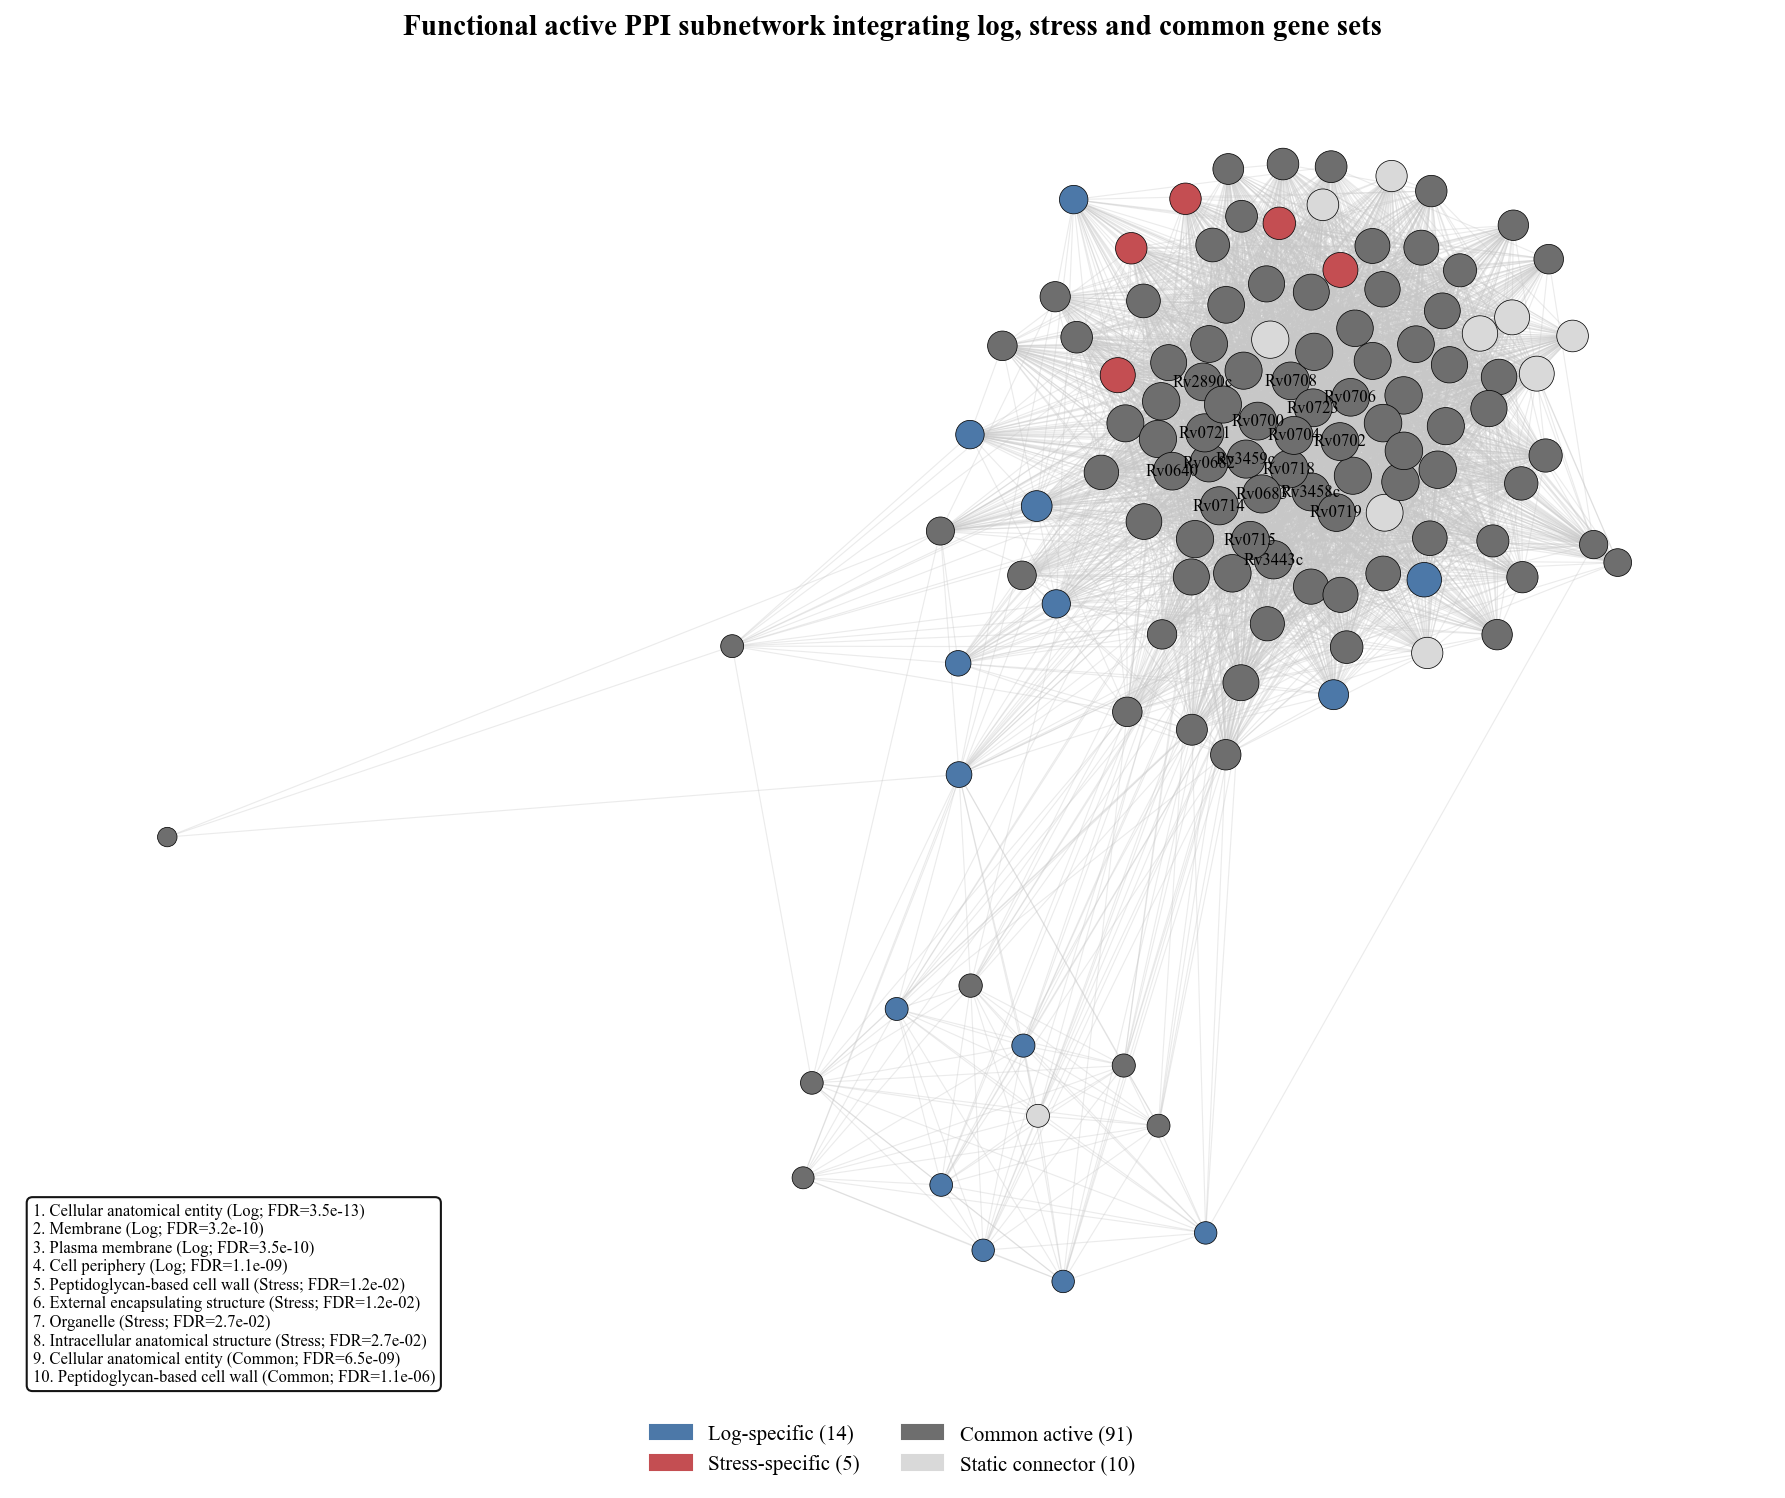

In [ ]:
# ── Figure 8: One combined 4-color functional active PPI network ─────────────
# Run this cell AFTER the enrichment section has created `enrich_condition`.
# It does NOT use community analysis and does NOT read duplicate/fragile CSV columns.

import textwrap
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams["font.family"] = "Times New Roman"

# -------------------------------------------------------------------------
# 1. Required objects check
# -------------------------------------------------------------------------
_required = ["G_static", "G_log", "G_stress", "enrich_condition", "OUTDIR"]
_missing = [x for x in _required if x not in globals()]
if _missing:
    raise NameError(
        "Missing required objects: " + ", ".join(_missing) +
        ". Run the network-construction and STRING enrichment sections first."
    )

# -------------------------------------------------------------------------
# 2. Define 4 biological node classes
# -------------------------------------------------------------------------
nodes_static = set(G_static.nodes())
nodes_log = set(G_log.nodes())
nodes_stress = set(G_stress.nodes())

log_specific_genes = nodes_log - nodes_stress
stress_specific_genes = nodes_stress - nodes_log
common_active_genes = nodes_log & nodes_stress
inactive_genes = nodes_static - (nodes_log | nodes_stress)

print("Network-state gene counts used for coloring:")
print(f"  Log-specific active genes    : {len(log_specific_genes):,}")
print(f"  Stress-specific active genes : {len(stress_specific_genes):,}")
print(f"  Common active genes          : {len(common_active_genes):,}")
print(f"  Static-only/inactive genes   : {len(inactive_genes):,}")

# -------------------------------------------------------------------------
# 3. Select enriched terms from condition-level enrichment only
#    This avoids the previous error from `specific_enrich` column detection.
# -------------------------------------------------------------------------
if enrich_condition is None or len(enrich_condition) == 0:
    raise ValueError("`enrich_condition` is empty. Run STRING enrichment first.")

enrich_for_network = enrich_condition.copy()

# Required standardized columns produced by the notebook enrichment wrapper.
required_cols = ["gene_set", "display_term", "fdr", "gene_ids"]
missing_cols = [c for c in required_cols if c not in enrich_for_network.columns]
if missing_cols:
    print("Available enrich_condition columns:")
    print(enrich_for_network.columns.tolist())
    raise ValueError(
        "enrich_condition is not in the standardized format. Missing: " + ", ".join(missing_cols) +
        ". Re-run the STRING enrichment wrapper cell that standardizes columns."
    )

# Use significant terms if available; otherwise use the top returned terms.
# This prevents stress/common terms from disappearing when strict FDR filtering is empty.
if "passed_fdr" not in enrich_for_network.columns:
    enrich_for_network["passed_fdr"] = enrich_for_network["fdr"].astype(float) <= 0.05

def _nonempty_gene_list(x):
    if isinstance(x, (list, tuple, set)):
        return len(x) > 0
    return pd.notna(x) and str(x).strip() not in ["", "[]", "nan", "None"]

enrich_for_network = enrich_for_network[enrich_for_network["gene_ids"].map(_nonempty_gene_list)].copy()
enrich_for_network["fdr"] = pd.to_numeric(enrich_for_network["fdr"], errors="coerce")
enrich_for_network = enrich_for_network.dropna(subset=["fdr"]).copy()

# Prefer biologically useful categories but do not require them.
preferred_categories = ["Process", "KEGG", "Function", "Keyword", "Component"]
if "category" in enrich_for_network.columns:
    preferred_df = enrich_for_network[enrich_for_network["category"].isin(preferred_categories)].copy()
    if len(preferred_df) > 0:
        enrich_for_network = preferred_df

# Select top terms from log active, stress active and common active sets.
TOP_TERMS_EACH = 4
wanted_sets = [
    "Log active network genes",
    "Stress active network genes",
    "Common active network genes",
]

selected_term_rows = []
for gene_set in wanted_sets:
    g = enrich_for_network[enrich_for_network["gene_set"].astype(str).eq(gene_set)].copy()
    if g.empty:
        print(f"WARNING: No enrichment rows found for: {gene_set}")
        continue
    # Prefer FDR-significant; fallback to top rows if no significant terms.
    g_sig = g[g["passed_fdr"].astype(bool)].copy()
    if g_sig.empty:
        g_sig = g.copy()
    g_sig = g_sig.sort_values("fdr", ascending=True).head(TOP_TERMS_EACH)
    selected_term_rows.append(g_sig)

if not selected_term_rows:
    raise ValueError("No log/stress/common enrichment terms available for the network plot.")

selected_terms = pd.concat(selected_term_rows, ignore_index=True)
selected_terms = selected_terms.drop_duplicates(subset=["gene_set", "display_term"]).reset_index(drop=True)

print("\nSelected enriched terms used for the network:")
display_cols = [c for c in ["gene_set", "category", "display_term", "fdr"] if c in selected_terms.columns]
display(selected_terms[display_cols])

# -------------------------------------------------------------------------
# 4. Extract genes from selected terms
# -------------------------------------------------------------------------
def _clean_gene(g):
    g = str(g).strip().replace(f"{TAXID}.", "") if "TAXID" in globals() else str(g).strip()
    return g

def _safe_gene_list(x):
    if isinstance(x, (list, tuple, set)):
        return sorted({_clean_gene(g) for g in x if str(g).strip()})
    if pd.isna(x):
        return []
    # Handles comma-separated strings if gene_ids was saved/reloaded.
    import re
    parts = re.split(r"[,;|\s]+", str(x))
    return sorted({_clean_gene(p) for p in parts if p.strip() and p.strip() not in ["[]", "nan", "None"]})

seed_genes = set()
term_summary = []
for _, row in selected_terms.iterrows():
    genes = set(_safe_gene_list(row["gene_ids"])) & nodes_static
    if len(genes) == 0:
        continue
    seed_genes.update(genes)
    term_summary.append({
        "gene_set": row["gene_set"],
        "term": row["display_term"],
        "fdr": row["fdr"],
        "genes_in_term": len(genes),
    })

print(f"\nSeed genes from selected enriched terms: {len(seed_genes):,}")
if len(seed_genes) == 0:
    raise ValueError("Selected enrichment terms contained no genes that matched G_static nodes.")

# -------------------------------------------------------------------------
# 5. Build one reduced functional PPI subnetwork
#    Start from selected functional genes, then add limited static connector genes.
# -------------------------------------------------------------------------
# Add connector genes that connect at least two seed genes. This provides the 4th color
# only where it helps network structure; it avoids plotting the whole static hairball.
connector_genes = set()
for n in nodes_static - seed_genes:
    try:
        n_seed_neighbors = len(set(G_static.neighbors(n)) & seed_genes)
    except Exception:
        n_seed_neighbors = 0
    if n_seed_neighbors >= 2:
        connector_genes.add(n)

MAX_CONNECTORS = 30
if len(connector_genes) > MAX_CONNECTORS:
    connector_genes = set(sorted(
        connector_genes,
        key=lambda n: len(set(G_static.neighbors(n)) & seed_genes),
        reverse=True
    )[:MAX_CONNECTORS])

plot_genes = seed_genes | connector_genes
H = G_static.subgraph(plot_genes).copy()

# Keep the plot readable.
# Remove isolates if enough connected nodes remain.
isolates = list(nx.isolates(H))
if H.number_of_nodes() - len(isolates) >= 12:
    H.remove_nodes_from(isolates)

MAX_NODES = 120
if H.number_of_nodes() > MAX_NODES:
    # Keep nodes with high degree in the displayed subnetwork, preserving all 4 states where possible.
    degree_H = dict(H.degree())
    # ensure some stress/log/common are retained by weighted rank
    def _rank_node(n):
        bonus = 0
        if n in log_specific_genes or n in stress_specific_genes:
            bonus = 10
        elif n in common_active_genes:
            bonus = 5
        return degree_H.get(n, 0) + bonus
    keep_nodes = sorted(H.nodes(), key=_rank_node, reverse=True)[:MAX_NODES]
    H = H.subgraph(keep_nodes).copy()
    isolates = list(nx.isolates(H))
    if H.number_of_nodes() - len(isolates) >= 12:
        H.remove_nodes_from(isolates)

print("\nFinal one-plot functional PPI network:")
print(f"  Nodes: {H.number_of_nodes():,}")
print(f"  Edges: {H.number_of_edges():,}")

# Save node table for checking.
def classify_node(n):
    if n in log_specific_genes:
        return "Log-specific"
    if n in stress_specific_genes:
        return "Stress-specific"
    if n in common_active_genes:
        return "Common active"
    return "Static connector"

node_table = pd.DataFrame({
    "gene": sorted(H.nodes()),
    "dynamic_state": [classify_node(n) for n in sorted(H.nodes())],
    "degree_in_displayed_network": [H.degree(n) for n in sorted(H.nodes())],
})
node_table.to_csv(OUTDIR / "Fig8_oneplot_4color_functional_network_nodes.csv", index=False)

pd.DataFrame(term_summary).to_csv(OUTDIR / "Fig8_oneplot_4color_selected_enriched_terms.csv", index=False)

# -------------------------------------------------------------------------
# 6. Plot: one network, 4 node colors, neutral edges
# -------------------------------------------------------------------------
NODE_COLORS = {
    "Log-specific": "#4C78A8",               # blue
    "Stress-specific": "#C44E52",            # red
    "Common active": "#6E6E6E",              # dark grey
    "Static connector": "#D9D9D9",  # light grey
}

pos = nx.spring_layout(H, seed=RANDOM_SEED if "RANDOM_SEED" in globals() else 42, k=0.55, iterations=350)

deg_H = dict(H.degree())
max_deg = max(deg_H.values()) if deg_H else 1

fig, ax = plt.subplots(figsize=(12, 10))

# Neutral edges only.
nx.draw_networkx_edges(
    H, pos,
    edge_color="#C7C7C7",
    width=0.55,
    alpha=0.35,
    ax=ax
)

# Draw less important classes first, important condition-specific classes last.
for state in ["Static connector", "Common active", "Log-specific", "Stress-specific"]:
    state_nodes = [n for n in H.nodes() if classify_node(n) == state]
    if not state_nodes:
        continue
    sizes = [80 + 260 * (deg_H[n] / max_deg) for n in state_nodes]
    nx.draw_networkx_nodes(
        H, pos,
        nodelist=state_nodes,
        node_color=NODE_COLORS[state],
        node_size=sizes,
        edgecolors="black",
        linewidths=0.35,
        ax=ax
    )

# Label only top connected genes.
TOP_LABELS = 18
label_nodes = sorted(H.nodes(), key=lambda n: deg_H[n], reverse=True)[:TOP_LABELS]
nx.draw_networkx_labels(
    H, pos,
    labels={n: n for n in label_nodes},
    font_size=8,
    font_family="Times New Roman",
    ax=ax
)

# Functional term summary box.
term_lines = []
for i, tr in enumerate(term_summary[:10], start=1):
    term = str(tr["term"])
    term = term if len(term) <= 48 else term[:45] + "..."
    fdr = tr["fdr"]
    fdr_text = f"FDR={fdr:.1e}" if pd.notna(fdr) else "FDR=NA"
    term_lines.append(f"{i}. {term} ({tr['gene_set'].replace(' active network genes','')}; {fdr_text})")

ax.text(
    0.01, 0.01,
    "\n".join(term_lines),
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="black", alpha=0.92)
)

legend_handles = [
    mpatches.Patch(color=NODE_COLORS["Log-specific"], label=f"Log-specific ({sum(classify_node(n)=='Log-specific' for n in H.nodes())})"),
    mpatches.Patch(color=NODE_COLORS["Stress-specific"], label=f"Stress-specific ({sum(classify_node(n)=='Stress-specific' for n in H.nodes())})"),
    mpatches.Patch(color=NODE_COLORS["Common active"], label=f"Common active ({sum(classify_node(n)=='Common active' for n in H.nodes())})"),
    mpatches.Patch(color=NODE_COLORS["Static connector"], label=f"Static connector ({sum(classify_node(n)=='Static connector' for n in H.nodes())})"),
]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.07),
    ncol=2,
    frameon=False,
    fontsize=10
)

ax.set_title(
    "Functional active PPI subnetwork integrating log, stress and common gene sets",
    fontsize=14,
    fontweight="bold"
)
ax.axis("off")
fig.tight_layout()

save_figure(fig, "Fig8_OnePlot_4Color_Functional_Active_PPI_Network")
plt.show()


## Section 12 — Results Summary

Run the cell below after executing all previous sections to print a consolidated summary and list all generated output files.


In [ ]:
print("=" * 60)
print("  RESULTS SUMMARY")
print("=" * 60)
print(f"[Static network]")
print(f"  Nodes : {G_static.number_of_nodes():,}")
print(f"  Edges : {G_static.number_of_edges():,}")

print(f"[Condition-specific networks]")
for label, G in [("Log", G_log), ("Stress", G_stress)]:
    print(f"  {label:6s} — nodes: {G.number_of_nodes():,}  edges: {G.number_of_edges():,}")

print(f"[Node / edge overlap]")


print(f"[Centrality-prioritized sets]")
print(f"  Log    : {len(core_log):,} genes")
print(f"  Stress : {len(core_stress):,} genes")
print(f"  Shared : {len(shared_core):,}  |  Log-only: {len(log_only_core):,}  |  Stress-only: {len(stress_only_core):,}")

print("[Functional enrichment gene sets]")
print(f"  Condition-level sets:") 
print(f"    Log active    : {len(condition_enrichment_sets.get('Log active network genes', [])):,}")
print(f"    Stress active : {len(condition_enrichment_sets.get('Stress active network genes', [])):,}")
print(f"    Common active : {len(condition_enrichment_sets.get('Common active network genes', [])):,}")
print(f"  Expression-rank-shift sets:")
print(f"    Log-biased    : {len(rank_shift_enrichment_sets.get('Log-biased active network genes', [])):,}")
print(f"    Stress-biased : {len(rank_shift_enrichment_sets.get('Stress-biased active network genes', [])):,}")

if 'enrich_condition' in globals() and enrich_condition is not None and not enrich_condition.empty:
    print(f"  Condition-level enrichment terms returned: {len(enrich_condition):,}")
    print(f"  Gene sets: {', '.join(enrich_condition['gene_set'].drop_duplicates().astype(str))}")
else:
    print("  Condition-level enrichment terms returned: 0")

if 'enrich_rank_shift' in globals() and enrich_rank_shift is not None and not enrich_rank_shift.empty:
    print(f"  Expression-rank-shift enrichment terms returned: {len(enrich_rank_shift):,}")
    print(f"  Gene sets: {', '.join(enrich_rank_shift['gene_set'].drop_duplicates().astype(str))}")
else:
    print("  Expression-rank-shift enrichment terms returned: 0")

print("[Generated PNG figures]")
for p in sorted(FIGDIR.glob("*.png")):
    print(f"  - {p.name}")

print("=" * 60)

  RESULTS SUMMARY
[Static network]
  Nodes : 3,789
  Edges : 30,029
[Condition-specific networks]
  Log    — nodes: 1,893  edges: 13,088
  Stress — nodes: 1,847  edges: 10,847
[Node / edge overlap]
[Centrality-prioritized sets]
  Log    : 1,367 genes
  Stress : 1,364 genes
  Shared : 940  |  Log-only: 427  |  Stress-only: 424
[Functional enrichment gene sets]
  Condition-level sets:
    Log active    : 1,893
    Stress active : 1,847
    Common active : 1,378
  Expression-rank-shift sets:
    Log-biased    : 472
    Stress-biased : 472
  Condition-level enrichment terms returned: 100
  Gene sets: Log active network genes, Stress active network genes, Common active network genes
  Expression-rank-shift enrichment terms returned: 45
  Gene sets: Log-biased active network genes, Stress-biased active network genes
[Generated PNG figures]
  - Fig8_OnePlot_4Color_Functional_Active_PPI_Network.png
